<a href="https://colab.research.google.com/github/studentradhika/Adaptive-Behavioral-Intelligence-System-for-Resource-Utilization-Optimization/blob/main/gpu_after%20_workload_monitoring_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 170M/170M [00:04<00:00, 41.1MB/s]


In [ ]:
class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64*6*6, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(-1, 64*6*6)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
model = Net().to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(5):

    running_loss = 0.0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss)

Epoch: 1 Loss: 604.477790594101
Epoch: 2 Loss: 470.6526555418968
Epoch: 3 Loss: 415.6148124933243
Epoch: 4 Loss: 374.43710029125214
Epoch: 5 Loss: 341.04827988147736


In [ ]:
!nvidia-smi

Fri Mar 13 14:37:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P0             28W /   70W |     273MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install gputil

  Preparing metadata (setup.py) ... done
  Created wheel for gputil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=aa1b82442d7532b22a1bbbbcecbb937b8185457359061a206013c75038bfc62f
  Stored in directory: /root/.cache/pip/wheels/92/a8/b7/d8a067c31a74de9ca252bbe53dea5f896faabd25d55f541037
Successfully built gputil


In [ ]:
import GPUtil
import time

for i in range(10):

    gpus = GPUtil.getGPUs()

    for gpu in gpus:
        print("Load:", gpu.load*100)
        print("Memory:", gpu.memoryUsed)
        print("Temp:", gpu.temperature)

    time.sleep(2)

Load: 0.0
Memory: 273.0
Temp: 61.0
Load: 0.0
Memory: 273.0
Temp: 61.0
Load: 0.0
Memory: 273.0
Temp: 61.0
Load: 0.0
Memory: 273.0
Temp: 61.0
Load: 0.0
Memory: 273.0
Temp: 61.0
Load: 0.0
Memory: 273.0
Temp: 61.0
Load: 0.0
Memory: 273.0
Temp: 61.0
Load: 0.0
Memory: 273.0
Temp: 61.0
Load: 0.0
Memory: 273.0
Temp: 61.0
Load: 0.0
Memory: 273.0
Temp: 62.0


In [ ]:
for epoch in range(20):

    running_loss = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss)

Epoch: 1 Loss: 307.4096415042877
Epoch: 2 Loss: 280.5198817849159
Epoch: 3 Loss: 253.42911291122437
Epoch: 4 Loss: 224.26440998911858
Epoch: 5 Loss: 200.22088906168938
Epoch: 6 Loss: 172.60270726680756
Epoch: 7 Loss: 146.88955874741077
Epoch: 8 Loss: 123.18924708664417
Epoch: 9 Loss: 104.39934059232473
Epoch: 10 Loss: 82.71539480984211
Epoch: 11 Loss: 67.13331351429224
Epoch: 12 Loss: 55.307410933077335
Epoch: 13 Loss: 43.67230238765478
Epoch: 14 Loss: 37.123594257980585
Epoch: 15 Loss: 28.167083580046892
Epoch: 16 Loss: 25.963004011660814
Epoch: 17 Loss: 29.178396251052618
Epoch: 18 Loss: 25.375981155782938
Epoch: 19 Loss: 24.220280919224024
Epoch: 20 Loss: 17.443140538409352


In [ ]:
!nvidia-smi

Fri Mar 13 14:49:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             34W /   70W |     273MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

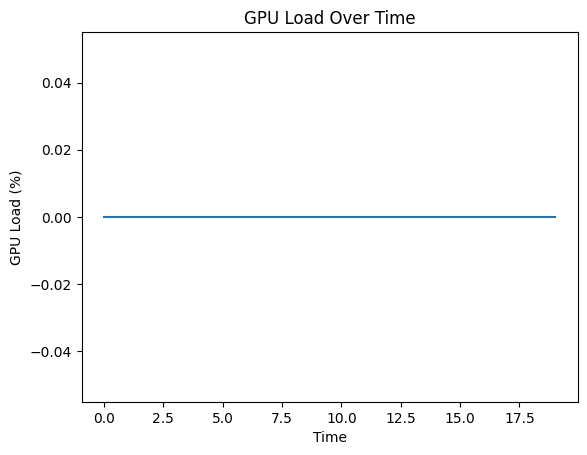

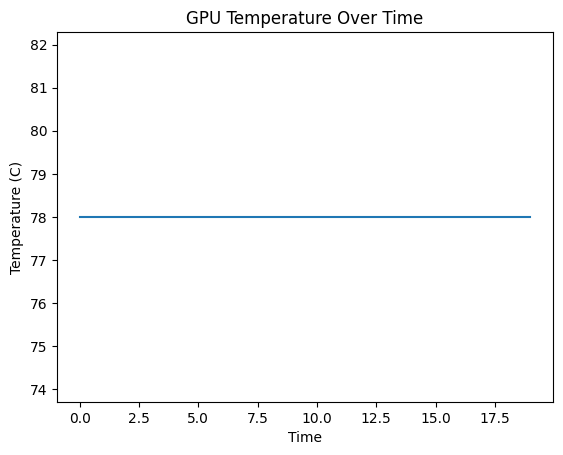

In [ ]:
import GPUtil
import time
import matplotlib.pyplot as plt

loads = []
temps = []

for i in range(20):

    gpus = GPUtil.getGPUs()

    for gpu in gpus:
        loads.append(gpu.load*100)
        temps.append(gpu.temperature)

    time.sleep(1)

plt.plot(loads)
plt.title("GPU Load Over Time")
plt.xlabel("Time")
plt.ylabel("GPU Load (%)")
plt.show()

plt.plot(temps)
plt.title("GPU Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.show()

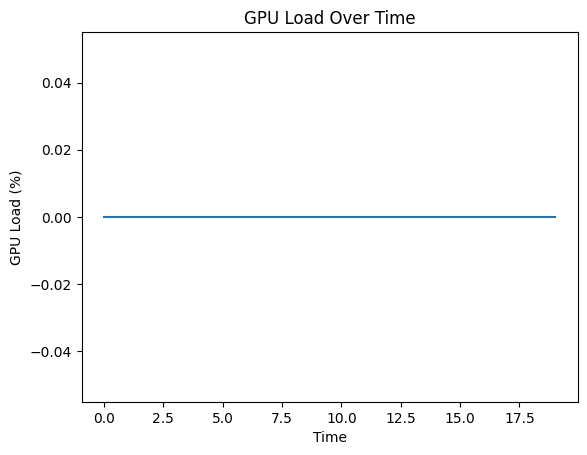

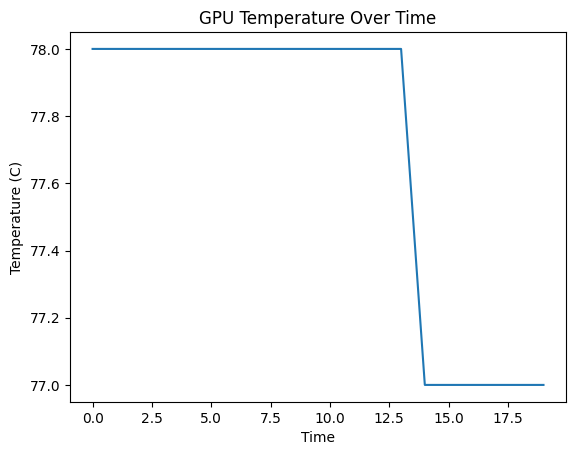

In [ ]:
import GPUtil
import time
import matplotlib.pyplot as plt

loads = []
temps = []

for i in range(20):

    gpus = GPUtil.getGPUs()

    for gpu in gpus:
        loads.append(gpu.load*100)
        temps.append(gpu.temperature)

    time.sleep(1)

plt.plot(loads)
plt.title("GPU Load Over Time")
plt.xlabel("Time")
plt.ylabel("GPU Load (%)")
plt.show()

plt.plot(temps)
plt.title("GPU Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.show()